In [43]:
from pathlib import Path as path
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import re
import math
import os
import copy
import matplotlib as mpl

In [2]:
box = 'storm'
gal_num = '2'
galaxy_name = f'{box}_{gal_num}'
numpix=8000

In [3]:
sd_outputs_path = (f'/home/giantsid/MAP/substructure_detection/sd_outputs')
segmented_path = path(f'{sd_outputs_path}/Segment/{galaxy_name}/segmented')
centers_path = path(f'{sd_outputs_path}/twod_exp_fit/{galaxy_name}/centers.txt')
mf_catalogs_path = path(f'/home/giantsid/MAP/matched_filter/mf_data/mf_catalogs/{galaxy_name}/')

In [4]:
# define useful values to be updated
area_of_interest = np.zeros((24, 89, 89), dtype=bool) # where 24 is the number of angles
min_obj = 0
max_obj = 0
my_extent = [-60,60,-60,60]

Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=0.0_a=0.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 11

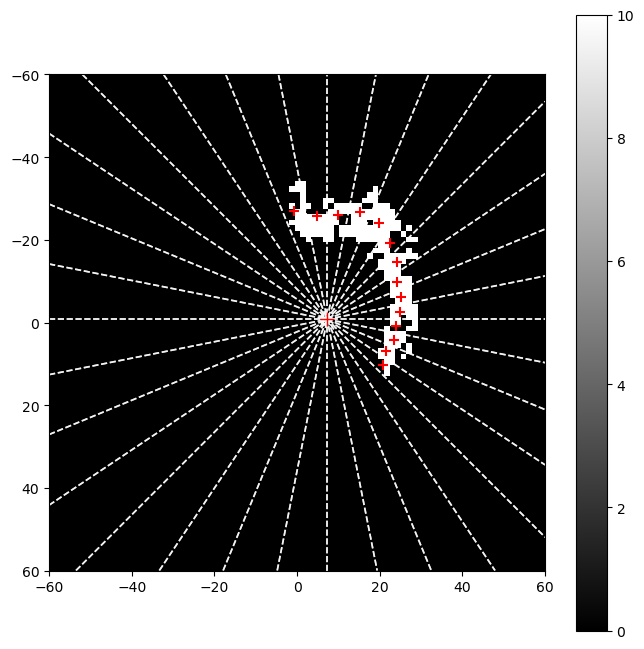

0
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=17.0_a=222.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

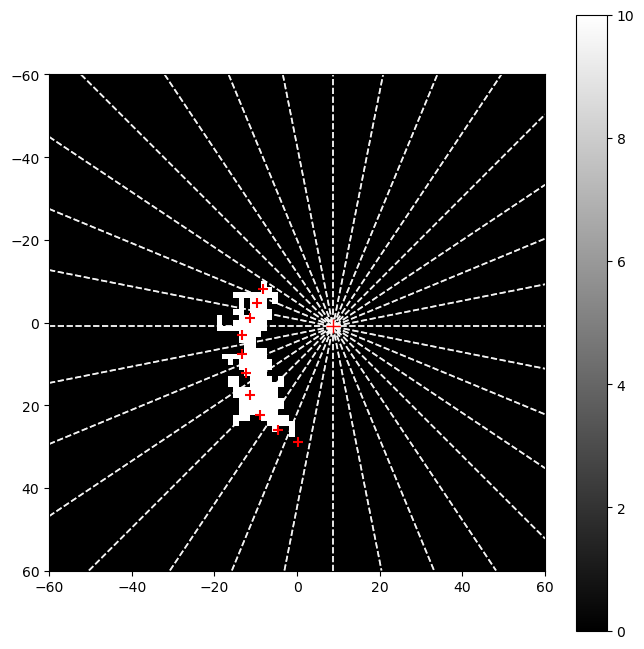

1
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=24.1_a=85.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110

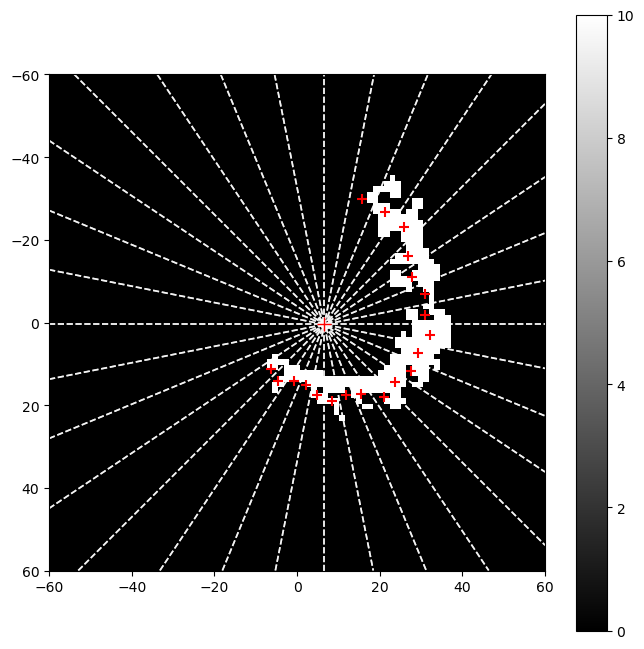

2
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=29.6_a=307.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

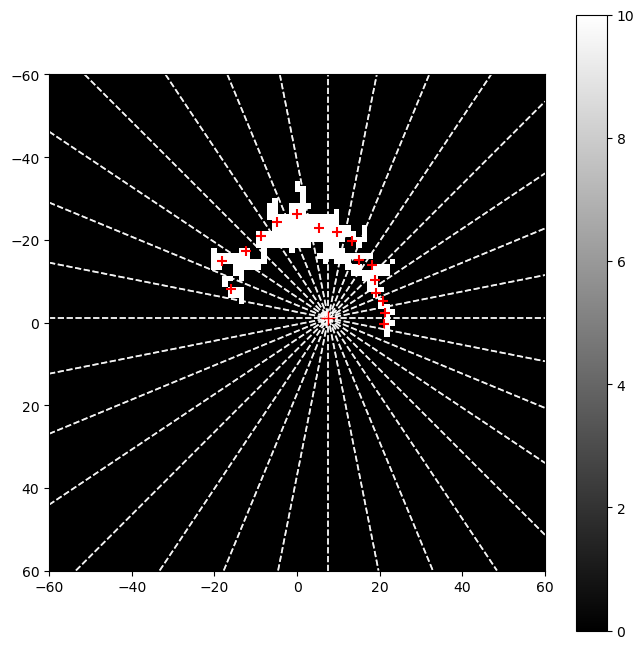

3
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=34.3_a=170.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

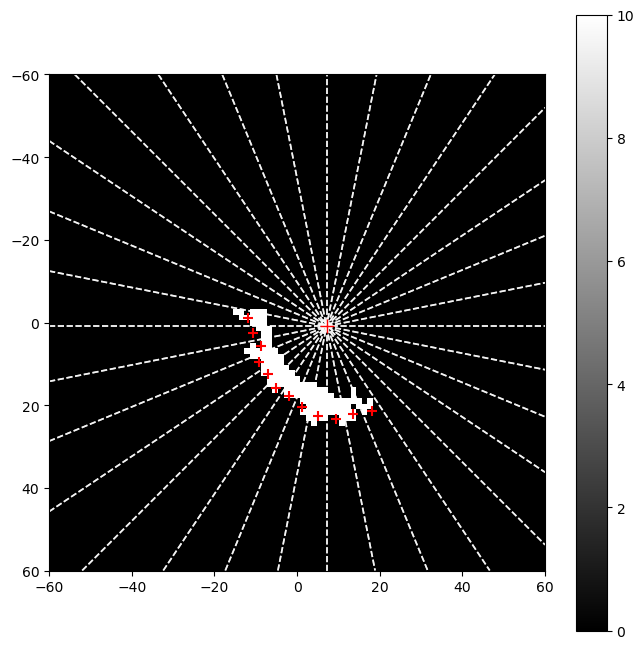

4
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=38.5_a=32.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110

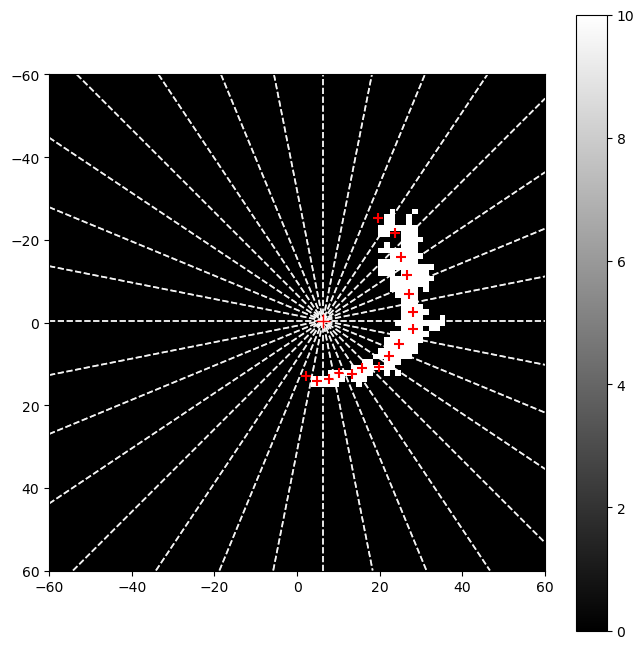

5
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=42.3_a=255.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

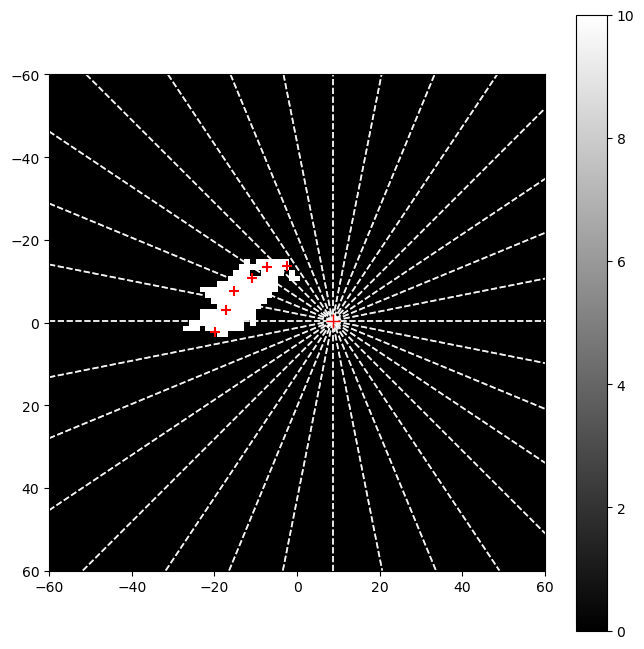

6
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=45.9_a=117.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

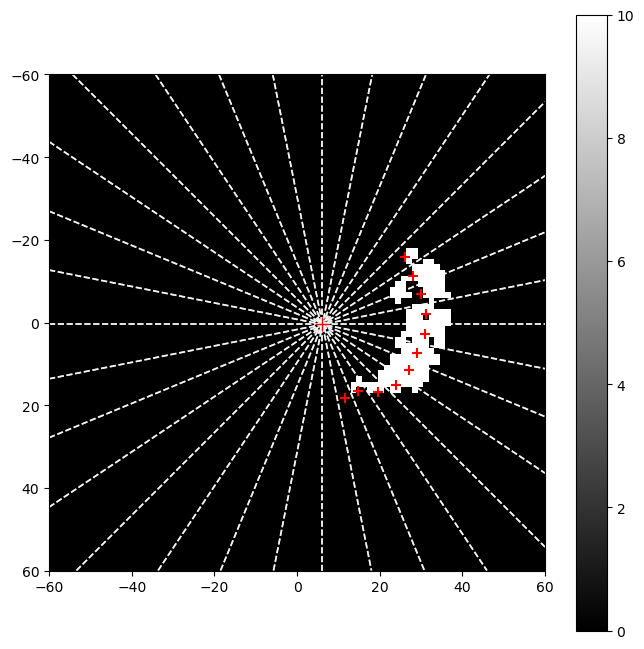

7
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=49.3_a=339.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

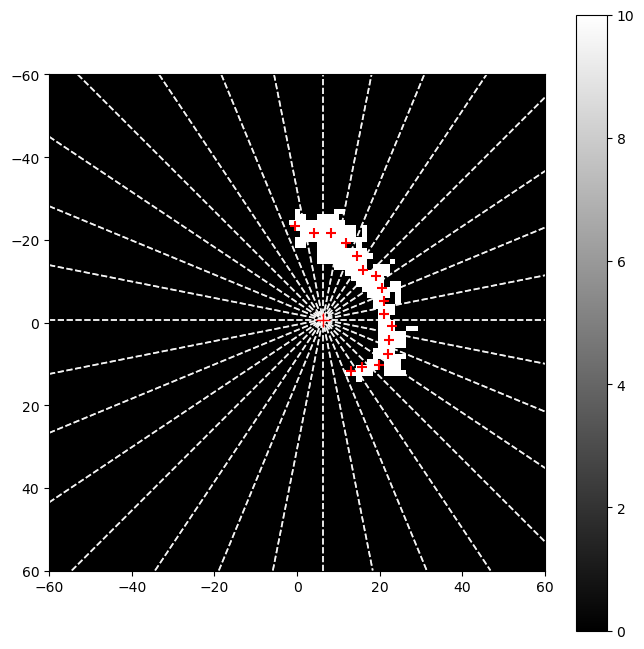

8
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=52.5_a=202.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

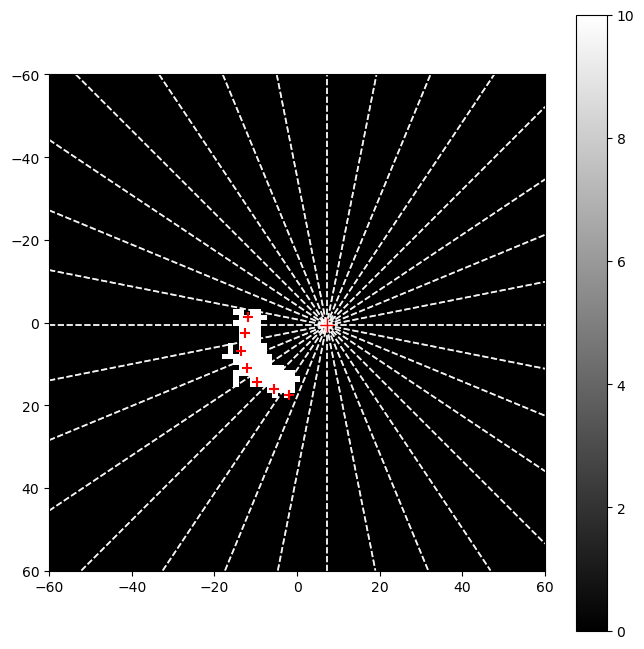

9
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=55.6_a=64.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110

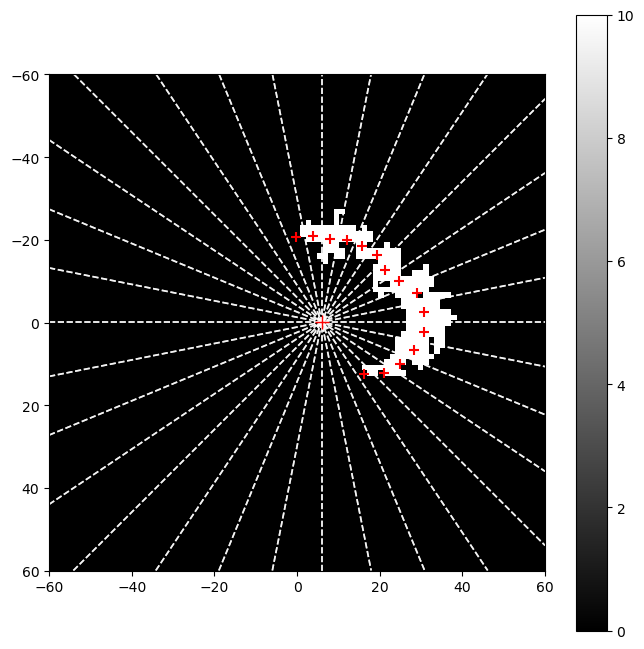

10
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=58.6_a=287.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

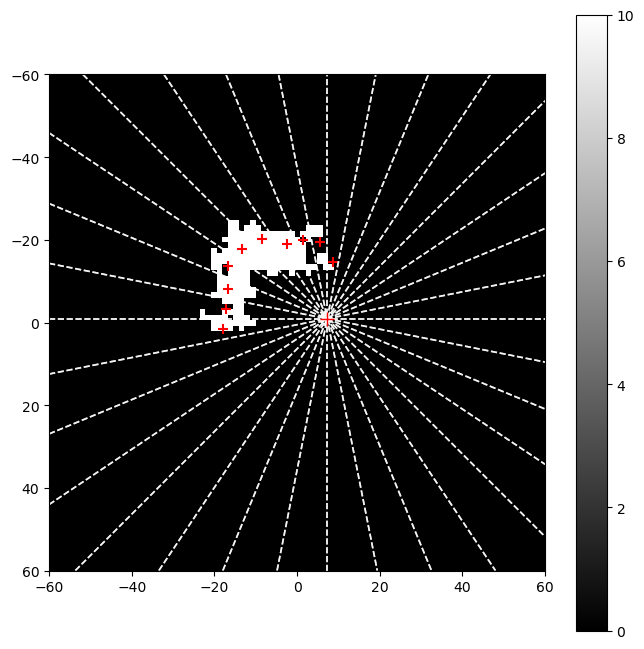

11
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=61.4_a=149.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

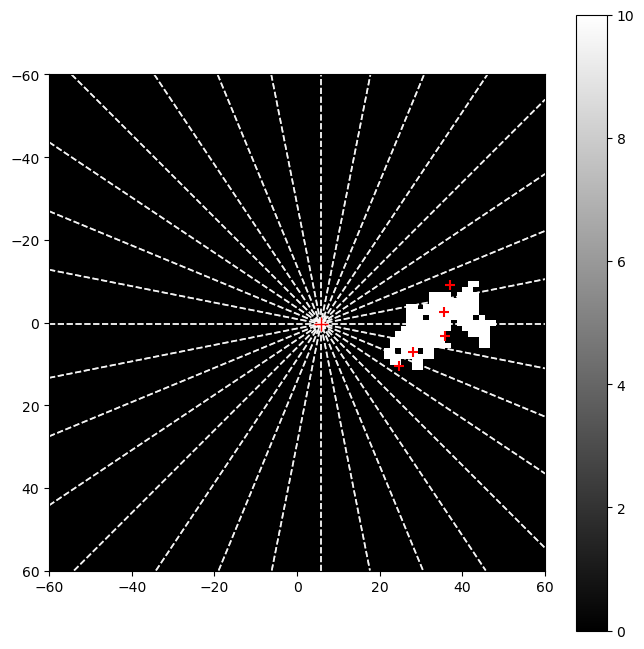

12
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=64.2_a=12.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

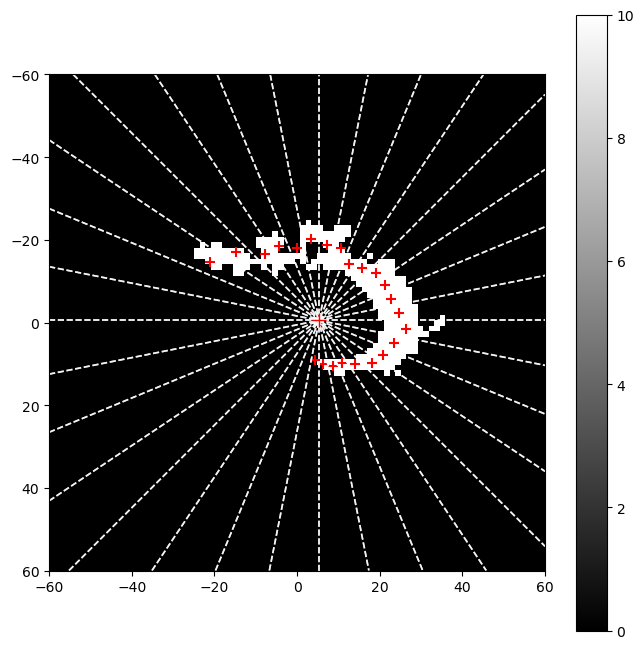

13
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=67.0_a=234.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

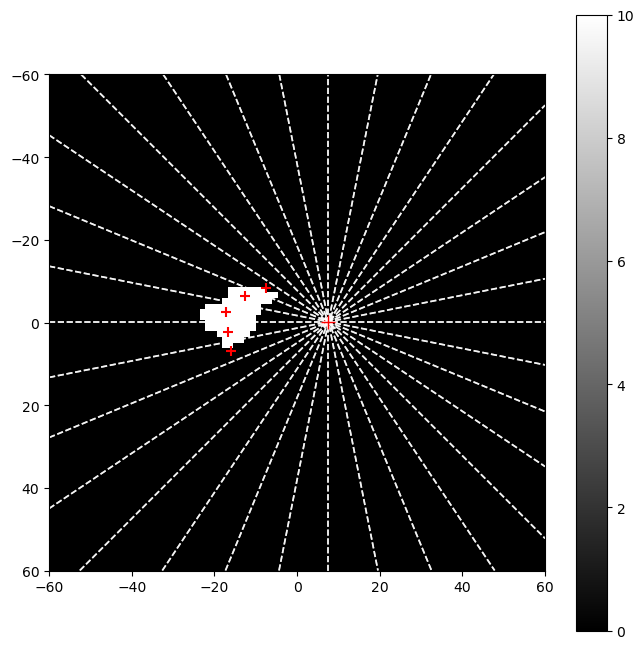

14
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=69.6_a=97.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

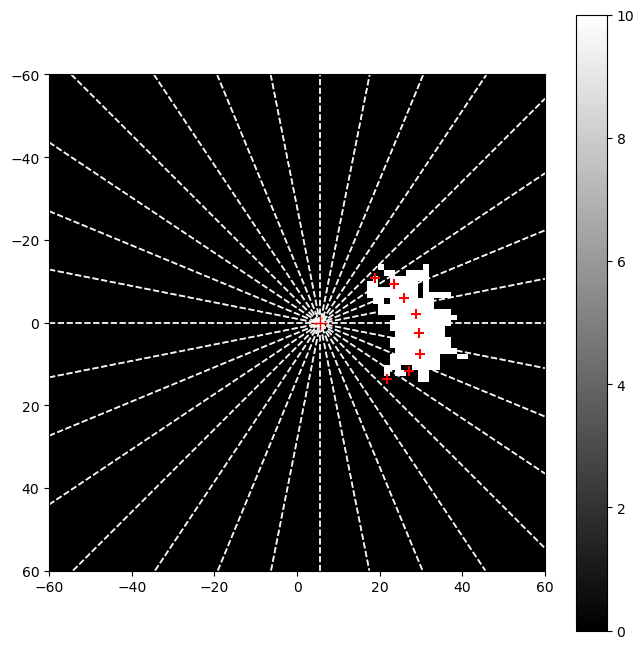

15
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=72.3_a=319.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

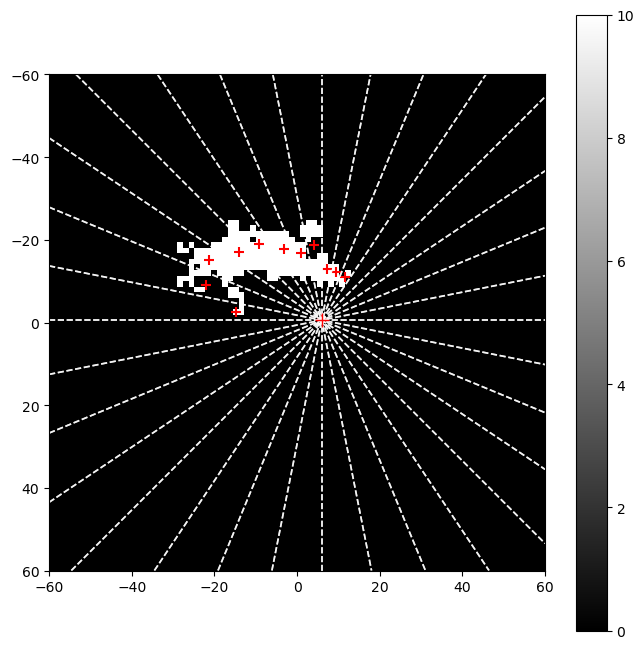

16
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=74.9_a=182.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

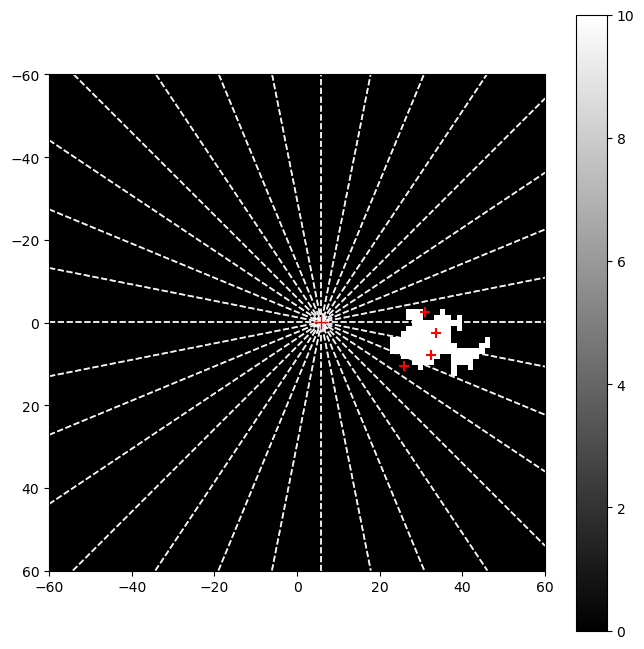

17
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=77.4_a=44.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

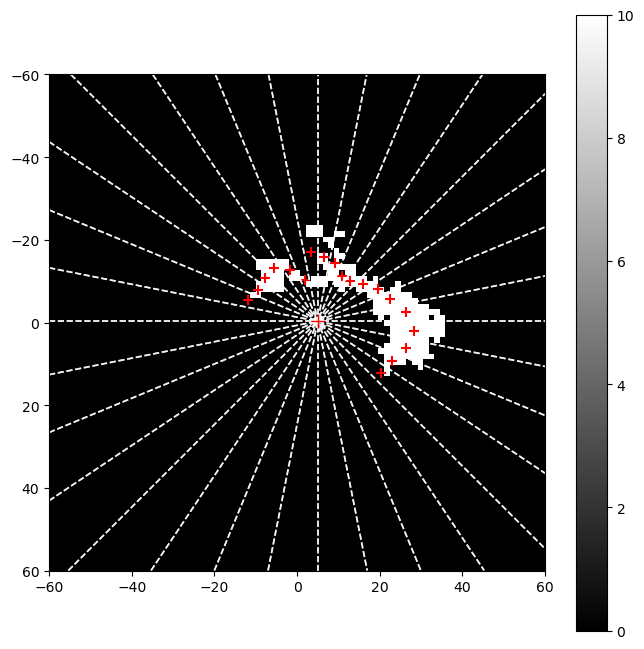

18
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=80.0_a=267.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

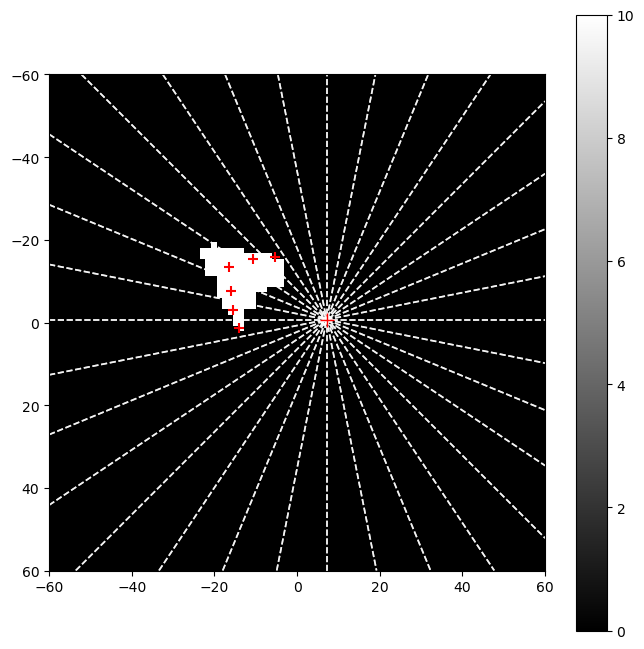

19
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=82.5_a=129.8_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

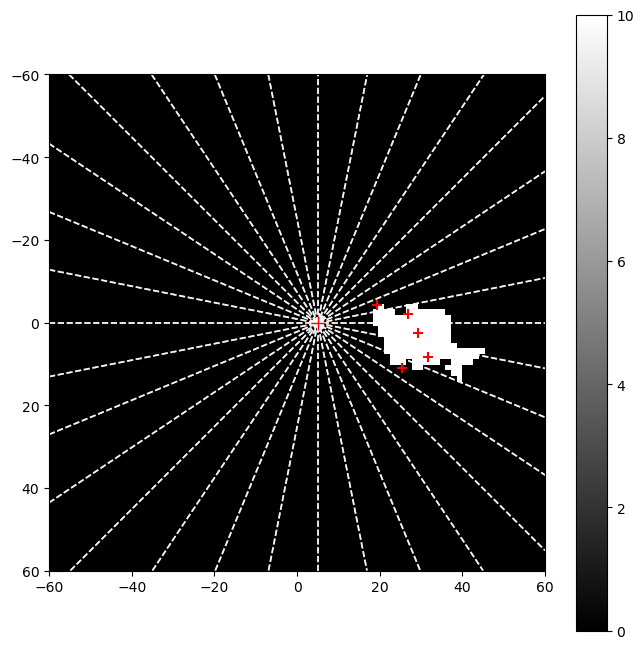

20
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=85.0_a=352.3_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

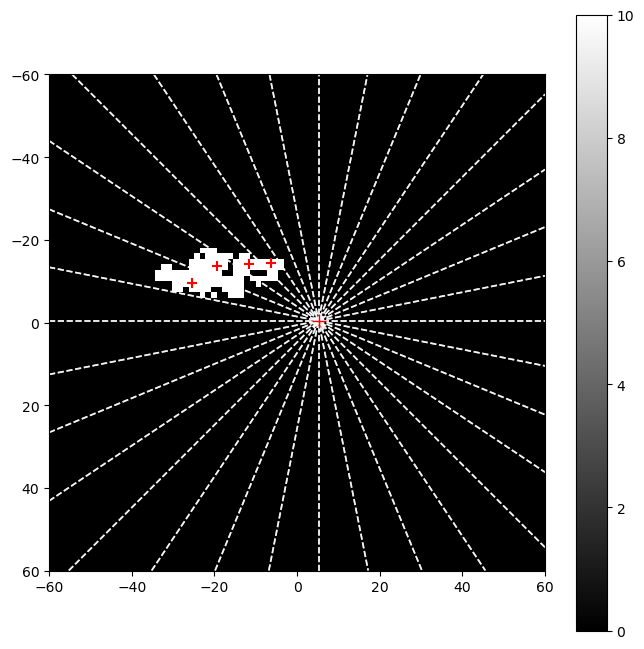

21
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=87.5_a=214.8_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 1

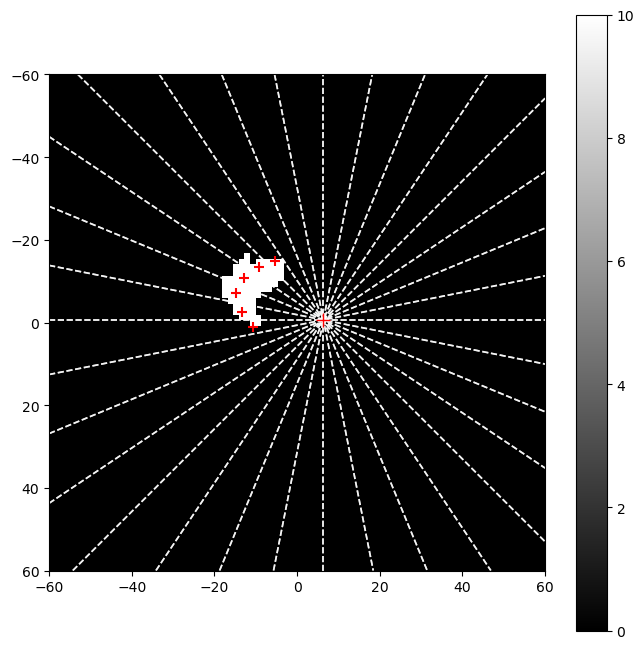

22
Filename: /home/giantsid/MAP/substructure_detection/sd_outputs/Segment/storm_2/segmented/segmented_storm_2_d=90.0_a=77.3_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SEGMENT-CONFIG    1 PrimaryHDU      51   ()      
  1  INPUT-NO-SKY    1 ImageHDU         8   (89, 89)   float32   
  2  CLUMPS        1 ImageHDU        11   (89, 89)   int32   
  3  OBJECTS       1 ImageHDU        11   (89, 89)   int32   
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 11

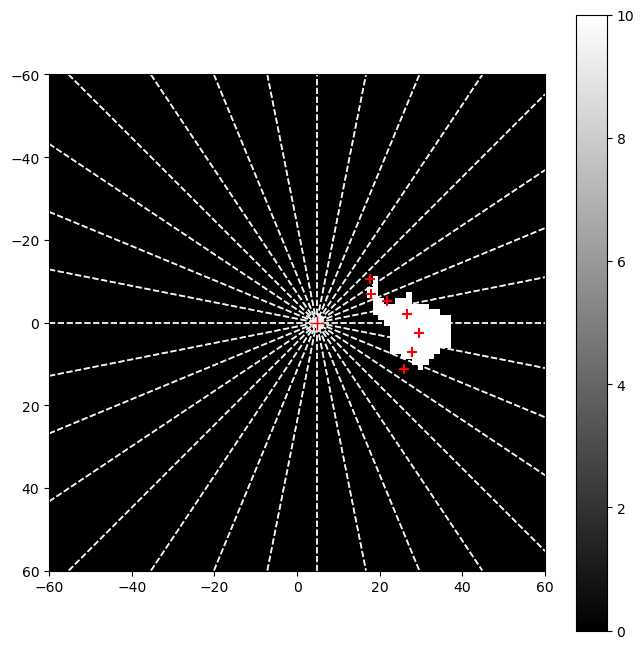

23


In [127]:
current_rotation = 0

for file in sorted(segmented_path.iterdir()):
    if file.is_file():
        
        hdul = fits.open(f'{segmented_path}/{file.name}')
        hdul.info()
        image_data = hdul[3].data

        # use centers calculated by twod_exp_fit
        x_center = 0
        y_center = 0
        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        target_message = 'center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}'
        with open(f'{centers_path}', 'r') as file:
            for line in file:
                if target_message in line: # assumes there is only one instance of the correct message
                    parts = line.strip().split(':')
                    coords = parts[1].split(',')
                    x_center = float(coords[0].strip())
                    y_center = float(coords[1].strip())

        # plot the bins (only for visual help)
        max_length = 89
        n_bins = 32  
        angles = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)
        
        fig, ax = plt.subplots(figsize=(8, 8))

        for angle in angles:
            if np.isclose(angle, np.pi/2) or np.isclose(angle, 3*np.pi/2):
                ax.axvline(x=x_center, color='white', linestyle='--', linewidth=1.2, alpha=0.8)
            else:
                slope = np.tan(angle)
                ax.axline(
                    (x_center, y_center), 
                    slope=slope, 
                    color='white', 
                    linestyle='--', 
                    linewidth=1.2, 
                    alpha=0.8
                )
        
        ax.plot(x_center, y_center, 'r+', markersize=10, label='Center')

        # identify the largest object
        objects, counts = np.unique(image_data, return_counts=True)
        # ... excluding background
        not_bg_mask = objects != 0
        objects = objects[not_bg_mask]
        counts = counts[not_bg_mask]
        # ... and excluding nan
        nan_index = np.where(np.isnan(objects))[0][0]
        wout_nan_objects = np.delete(objects, nan_index)
        wout_nan_counts = np.delete(counts, nan_index)
        i_max = np.argmax(wout_nan_counts)
        print(wout_nan_objects)

        # remove all objects except the largest
        non_largest_mask = image_data != objects[i_max]
        image_data[non_largest_mask] = 0
        interest_obj = objects[i_max]

        # to mask the area of the matched filter
        area_of_interest[current_rotation, :, :] = image_data == interest_obj

        # find data of interest (non-background and of largest object)
        x_of_interest = []
        y_of_interest = []

        for r_idx, row in enumerate(image_data):
            for c_idx, val in enumerate(row):
                if val == interest_obj:
                    # scale the data size (89x89) to the plot size (120x120) 
                    scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
                    scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
                    x_of_interest.append(scaled_c) # try switching columns and rows
                    y_of_interest.append(scaled_r)

        # number of pixels of interest
        n_of_interest = len(x_of_interest)

        # calculate the average readius of each bin
        x_delta = [n - x_center for n in x_of_interest]
        y_delta = [n - y_center for n in y_of_interest]

        theta = [0] * n_of_interest

        for i in range(len(x_delta)):
            theta[i] = np.mod(math.atan2(y_delta[i],x_delta[i]), 2*np.pi)

        bin_size = 2*np.pi/n_bins

        ang_bin = [0] * n_of_interest
        for i in range(len(theta)):
            ang_bin[i] = int(np.floor(theta[i]/bin_size))

        radii = [0] * n_of_interest
        for i in range(n_of_interest):
            radii[i] = np.sqrt(x_delta[i]**2 + y_delta[i]**2)

        avg_radii = [0] * n_bins

        for j in range(n_bins):
            radii_sum = 0
            radii_counter = 0
            for i in range(len(ang_bin)):
                if ang_bin[i] == j:
                    radii_sum = radii_sum + radii[i]
                    radii_counter = radii_counter + 1
            if radii_counter == 0:
                radii_average = 0
            else:
                radii_average = radii_sum / radii_counter
            avg_radii[j] = radii_average
        avg_radii = np.array(avg_radii)

        # plot points for the average radius at the angular midpoint of each bin
        angles = np.linspace(0, 2*np.pi, n_bins, endpoint=False)
        angles = (angles + bin_size / 2)

        x_ang = avg_radii * np.cos(angles) + x_center
        y_ang = -avg_radii * np.sin(angles) + y_center

        min_obj = np.nanmin(image_data)
        max_obj = np.nanmax(image_data)

        plt.scatter(x_ang, y_ang, color='red', marker='+', s=50)
        plt.imshow(image_data, extent = my_extent, \
                    cmap = 'gray', vmin = 0, vmax = 10)
        print(max_obj)
    
        plt.colorbar()
        plt.gca().invert_yaxis()
        plt.show()
        hdul.close()
        
        print(current_rotation)
        
        current_rotation = current_rotation + 1

In [6]:
def find_large_outliers(data, multiplier=1.5):
    """Finds only large, extreme upper outliers while ignoring NaNs and small values."""
    data = np.array(data)
    
    # Calculate upper quartile parameters ignoring NaN
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    
    # Establish a high upper fence
    upper_bound = q3 + (multiplier * iqr)
    
    # Extract only values exceeding this high threshold
    outlier_indices = np.where(data > upper_bound)
    outlier_values = data[outlier_indices]
    
    return outlier_values#, outlier_indices, upper_bound

In [7]:
#This is an entirely new functin I found using the internet + AI

def ray_cells_in_grid(x0, y0, dx, dy, width, height):
    """
    Walk a ray starting at (x0, y0) in direction (dx, dy) through a unit
    grid, stopping as soon as it leaves a `width` x `height` grid
    (valid cell indices 0..width-1, 0..height-1).
 
    Returns the list of (i, j) cells the ray passes through, in order,
    starting with the cell containing (x0, y0). len(result) is the
    pixel/cell count.
 
    (dx, dy) is just a direction -- it doesn't need to be normalized,
    only its sign and ratio matter. Corner case: if the ray passes
    exactly through a grid corner, it jumps diagonally to the next cell
    rather than also counting the two cells that only touch at that
    point.
    """
    if dx == 0 and dy == 0:
        raise ValueError("direction vector (dx, dy) cannot be (0, 0)")
 
    i, j = math.floor(x0), math.floor(y0)
    if not (0 <= i < width and 0 <= j < height):
        return []
    cells = [(x0,y0),(i, j)]
 
    step_i = 1 if dx > 0 else (-1 if dx < 0 else 0)
    step_j = 1 if dy > 0 else (-1 if dy < 0 else 0)
 
    # tMaxX/tMaxY: parametric distance to the next vertical/horizontal
    # grid line. tDeltaX/tDeltaY: how much that increases per cell.
    if dx != 0:
        next_x = i + (1 if dx > 0 else 0)
        tMaxX = (next_x - x0) / dx
        tDeltaX = abs(1.0 / dx)
    else:
        tMaxX = math.inf
        tDeltaX = math.inf
 
    if dy != 0:
        next_y = j + (1 if dy > 0 else 0)
        tMaxY = (next_y - y0) / dy
        tDeltaY = abs(1.0 / dy)
    else:
        tMaxY = math.inf
        tDeltaY = math.inf
 
    while True:
        if tMaxX < tMaxY:
            tMaxX += tDeltaX
            i += step_i
        elif tMaxY < tMaxX:
            tMaxY += tDeltaY
            j += step_j
        else:
            tMaxX += tDeltaX
            tMaxY += tDeltaY
            i += step_i
            j += step_j
 
        if not (0 <= i < width and 0 <= j < height):
            break
        cells.append((i, j))
        if len(cells)>=11:
            break
 
    return cells

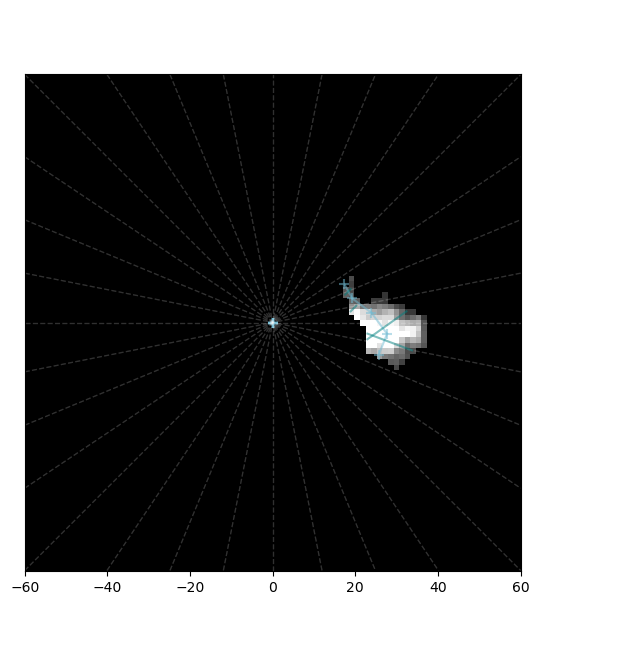

In [147]:
current_rotation = 23
ratio = 0
length_array = []
width_array = []
ratio_array = []

file_name_path=(f'{mf_catalogs_path}/mf_storm_2_d=90.0_a=77.3_pix=8000.fits')
        
# matched filtered object of interest
hdul = fits.open(f'{file_name_path}')
image_data = np.squeeze(hdul[0].data)
image_data[~area_of_interest[current_rotation, :, :]] = np.nan

# use centers calculated by twod_exp_fit
x_center = 0
y_center = 0
numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file_name_path}')]
angles = numbers[1:-1]
d = angles[0]
a = angles[1]
target_message = 'center of ' f'{box}' ' ' f'{gal_num}' ' at d=' f'{d}' ' and a=' f'{a}'
with open(f'{centers_path}', 'r') as file:
    for line in file:
        if target_message in line: # assumes there is only one instance of the correct message
            parts = line.strip().split(':')
            coords = parts[1].split(',')
            x_center = float(coords[0].strip())
            y_center = float(coords[1].strip())

# plot the bins (only for visual help)
max_length = 89
n_bins = 32  
angles = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)

fig, ax = plt.subplots(figsize=(8, 8))

for angle in angles:
    if np.isclose(angle, np.pi/2) or np.isclose(angle, 3*np.pi/2):
        ax.axvline(x=x_center, color='white', linestyle='--', linewidth=1, alpha=0.1)
    else:
        slope = np.tan(angle)
        ax.axline(
            (x_center, y_center), 
            slope=slope, 
            color='white', 
            linestyle='--', 
            linewidth=1, 
            alpha=0.1
        )

#ax.plot(x_center, y_center, 'o', color='lightcoral', markersize=10, label='Center')

outliers = find_large_outliers(np.unique(image_data))
outlier_mask = np.isin(image_data, outliers)
image_data[outlier_mask] = np.nan

x_of_interest = []
y_of_interest = []
val_of_interest = []

for r_idx, row in enumerate(image_data):
    for c_idx, val in enumerate(row):
        if ~np.isnan(val):
            val_of_interest.append(val)
            # scale the data size (89x89) to the plot size (120x120) 
            scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
            scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
            x_of_interest.append(scaled_c) # try switching columns and rows
            y_of_interest.append(scaled_r)

# number of pixels of interest
n_of_interest = len(x_of_interest)

# calculate the average readius of each bin
x_delta = [n - x_center for n in x_of_interest]
y_delta = [n - y_center for n in y_of_interest]

theta = [0] * n_of_interest

for i in range(len(x_delta)):
    theta[i] = np.mod(math.atan2(y_delta[i],x_delta[i]), 2*np.pi)

bin_size = 2*np.pi/n_bins

ang_bin = [0] * n_of_interest
for i in range(len(theta)):
    ang_bin[i] = int(np.floor(theta[i]/bin_size))

radii = [0] * n_of_interest
for i in range(n_of_interest):
    radii[i] = np.sqrt(x_delta[i]**2 + y_delta[i]**2)

avg_radii = [0] * n_bins

for j in range(n_bins):
    numerator = 0
    denominator = 0
    for i in range(len(ang_bin)):
        if ang_bin[i] == j:
            numerator = numerator + val_of_interest[i]
            denominator = denominator + val_of_interest[i]/radii[i]
    if denominator == 0:
        radii_average = 0
    else:
        radii_average = numerator/denominator
    avg_radii[j] = radii_average
avg_radii = np.array(avg_radii)

# plot points for the average radius at the angular midpoint of each bin
angles = np.linspace(0, 2*np.pi, n_bins, endpoint=False)
angles = (angles + bin_size / 2)

x_ang = avg_radii * np.cos(angles) + x_center
y_ang = -avg_radii * np.sin(angles) + y_center

cmap = plt.cm.gray.copy() # brighter areas represent higher star density
cmap.set_bad(color='black')

# set value scale AFTER the center is removed
min_obj = np.nanmin(image_data)
max_obj = np.nanmax(image_data)

plt.scatter(x_ang, y_ang, color='#72BCD4', marker='+', s=50, alpha=0.5)

total_dist = 0
stream_width_counter = 0
stream_width_total = 0

for i in range(n_bins): #or n_bins for real. Note this all falls apart if a midpoint is not actually within a stream.
    
    p1 = i
    p2 = np.mod(i+1, n_bins) #Enables looping from final bin to first bin
    
    x_sep = x_ang[p1]-x_ang[p2]
    y_sep = y_ang[p1]-y_ang[p2]

    dist = 0
    
    if (x_ang[p1] != x_center or y_ang[p1] != y_center) and (x_ang[p2] != x_center or y_ang[p2] != y_center): 
        dist = np.sqrt(x_sep**2 + y_sep**2) #Distance for this specific pair
        total_dist = total_dist + dist  #Total accumulated distance


        plt.plot([x_ang[p1], x_ang[p2]], [y_ang[p1], y_ang[p2]], color = '#72BCD4', alpha=0.5) #Line from point 1 to point 2

    x_mid = (x_ang[p1]+x_ang[p2])/2
    y_mid = (y_ang[p1]+y_ang[p2])/2
    #plt.scatter(x_mid,y_mid, color = 'green', s=20) #Plots midpoints between any two given points

    x_mid_as_grid = round((60+x_mid)*89/120) #Converts midpoints into grid coordinates
    y_mid_as_grid = 89-round((60+y_mid)*89/120)


    if x_sep == 0 and y_sep == 0: 
        pass
        
    else: 
        cells_1 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, y_sep, x_sep, 89, 89) #Lists all cells in line in one direction from muidpoing
        cells_2 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, -y_sep, -x_sep, 89, 89) #Lists all cells in opposite direction

        accept_limit = 4

        limit_1 = 0
        for n in range(len(cells_1)):
            if np.isnan(image_data[cells_1[n][1]][cells_1[n][0]]):
                break_counter = 0
                for m in range(accept_limit):
                    if n+m <= len(cells_1):
                        if np.isnan(image_data[cells_1[n+m-1][1]][cells_1[n+m-1][0]]):
                            break_counter = break_counter + 1
                        else:
                            break
                    else:
                        break
                limit_1 = n
                if break_counter == accept_limit:
                    break
            limit_1 = n

        limit_2 = 0
        for n in range(len(cells_2)):
            if np.isnan(image_data[cells_2[n][1]][cells_2[n][0]]):
                break_counter = 0
                for m in range(accept_limit):
                    if n+m <= len(cells_2):
                        if np.isnan(image_data[cells_2[n+m-1][1]][cells_2[n+m-1][0]]):
                            break_counter = break_counter + 1
                        else:
                            break
                    else:
                        break
                limit_2 = n
                if break_counter == accept_limit:
                    break
            limit_2 = n
        
        cells_1_culled = [[x, y] for x, y in cells_1[:limit_1] if not np.isnan(image_data[y][x])]
        cells_2_culled = [[x, y] for x, y in cells_2[:limit_2] if not np.isnan(image_data[y][x])]

        
        if len(cells_1_culled)!=0 and len(cells_2_culled)!=0:

            
            cell_first = cells_1_culled[-1] #Selects the farthest cell from the culled population
            cell_last = cells_2_culled[-1]


            cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  #Coordintes of centers of endpoint cells in image coordinates
            cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89

            cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
            cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 

            plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal', alpha=0.5) #Plots line connecting endpoints
            stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)


            

            stream_width_counter = stream_width_counter + 1
            stream_width_total = stream_width_total + stream_width

        elif len(cells_1_culled)==0 and len(cells_2_culled)!=0:

            cell_first = cells_2_culled[0] #Selects the farthest cell from the culled population
            cell_last = cells_2_culled[-1]


            cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  #Coordintes of centers of endpoint cells in image coordinates
            cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89

            cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
            cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 

            plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal', alpha=0.5) #Plots line connecting endpoints
            stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
            
          

            

            stream_width_counter = stream_width_counter + 1
            stream_width_total = stream_width_total + stream_width


        elif len(cells_1_culled)!=0 and len(cells_2_culled)==0:

            cell_first = cells_1_culled[0] #Selects the farthest cell from the culled population
            cell_last = cells_1_culled[-1]


            cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  #Coordintes of centers of endpoint cells in image coordinates
            cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89

            cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
            cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 

            plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal', alpha=0.5) #Plots line connecting endpoints
            stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
            
            
            

            stream_width_counter = stream_width_counter + 1
            stream_width_total = stream_width_total + stream_width
        

if stream_width_counter != 0:
    avg_width = stream_width_total/stream_width_counter
    ratio = total_dist/avg_width
else:
    avg_width = np.nan
    ratio = np.nan

# Plot
current_cmap = copy.copy(mpl.colormaps['gray'])
current_cmap.set_bad(color='black')

# 2. Plot the image using the modified colormap
plt.imshow(image_data, extent=[-60, 60, -60, 60], cmap=current_cmap, vmin=0, vmax=10)

length_array.append(total_dist)
width_array.append(avg_width)
ratio_array.append(ratio)

cbar = plt.colorbar(orientation='vertical')
if cbar.solids is not None:
    cbar.solids.set_alpha(0)
if hasattr(cbar, 'lines') and isinstance(cbar.lines, list):
    for line in cbar.lines:
        line.set_alpha(0)
cbar.outline.set_alpha(0)
cbar.ax.tick_params(axis='both', colors=(0,0,0,0), labelcolor=(0,0,0,0))

plt.gca().xaxis.set_visible(True)
plt.gca().yaxis.set_visible(False)
plt.gca().spines['bottom'].set_visible(True)

plt.gca().invert_yaxis()

plt.savefig('stream_storm_90.0.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
hdul.close()

In [9]:
print(length_array)
print(width_array)
print(ratio_array)

[57.80749504613998, 42.44231733248339, 86.41019013088074, 64.30593412315854, 42.37588767591441, 54.998111018373386, 25.371036174045017, 41.975643755428656, 55.25019757640903, 24.817812699051156, 59.3434721867675, 40.59727941969183, 31.67347371519239, 84.61648536310726, 16.13856792256973, 27.968659511149422, 49.81250445191047, 12.941776902599745, 63.11016326559014, 24.18331792454063, 17.92397402484898, 23.75135644672104, 20.35182550860369, 21.51350134921674]
[5.924722606453122, 8.790747098176801, 5.488879476685379, 4.66681780267266, 4.7580300385625165, 5.32143530140832, 7.817785997616291, 7.341590902943807, 4.7543717919286665, 5.890790254658382, 5.764998845394069, 7.580556765415073, 8.296874281095374, 5.176294351165141, 7.358936130832278, 10.134178236978759, 8.341335836267504, 14.831683180925811, 6.193497668134588, 7.680627975826509, 11.946006924448804, 8.273529820581107, 5.797930898523909, 6.733063866440342]
[9.756996046224492, 4.828067154984576, 15.742774185135154, 13.779396762892885,

In [10]:
def fibonacci_angler(n):

    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/((n-1)) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio
    

    return declination_array, azimuthal_array

declination_array, azimuthal_array = fibonacci_angler(24)

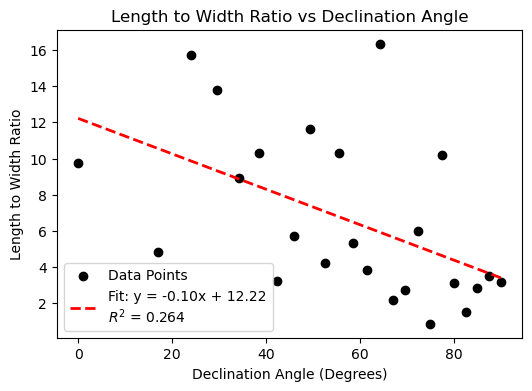

In [11]:
x = declination_array * 180 / (np.pi)
y = ratio_array

m, b = np.polyfit(x, y, deg=1)
y_pred = m * x + b

r_matrix = np.corrcoef(x, y)
r_value = r_matrix[0, 1]
r_squared = r_value ** 2

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(x, y, color='black', label='Data Points')
ax.plot(x, y_pred, color='red', linestyle='--', linewidth=2, 
        label=f'Fit: y = {m:.2f}x + {b:.2f}\n$R^2$ = {r_squared:.3f}')

ax.set_xlabel("Declination Angle (Degrees)")
ax.set_ylabel("Length to Width Ratio")
ax.set_title("Length to Width Ratio vs Declination Angle")

ax.legend()

ratio_v_angle_path=path(f'/home/giantsid/MAP/stream_analysis/stfit_outputs/{galaxy_name}/{galaxy_name}_ratio_v_angle.png')
ratio_v_angle_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ratio_v_angle_path)

plt.show()

In [12]:
lw_path=path(f'/home/giantsid/MAP/stream_analysis/stfit_outputs/{galaxy_name}/lw.txt')
lw_path.parent.mkdir(parents=True, exist_ok=True)

In [13]:
if os.path.exists(lw_path):
    os.remove(lw_path)

for i in range(len(ratio_array)):
    with open(f'{lw_path}', 'a') as file:   
        file.write('center of ' f'{galaxy_name}' ' at d=' f'{x[i]:.1f}' ': length=' f'{length_array[i]}' ', width=' f'{width_array[i]}' ', length-to-width ratio=' f'{ratio_array[i]}' '\n')